In [1]:
# 1) Install dependencies
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn
!pip install arabert
!pip install farasapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 15.0 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=bc7659a73afdf75712a2623924e59daa6d988a68beac84a57405b3026c44d00e
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji


In [2]:
# 2) Imports
import os
import re
import regex
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [3]:
# 3) Set random seeds
import torch
# If there's a GPU available...
if torch.cuda.is_available():
    # Tell PyTorch to use the GPU.

    device = torch.device("cuda")
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Mon Jun 22 10:06:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |            

In [4]:
# 4) Upload datasets
from google.colab import files

print("Step 1: Upload ASTD file (Tweets.txt)")
uploaded = files.upload()
ASTD_FILE = "Tweets.txt"

print("\nStep 2: Upload ArSarcasm-v2 train file (ArSarcasm-v2_train.csv)")
uploaded2 = files.upload()

print("\nStep 3: Upload ArSarcasm-v2 test file (ArSarcasm-v2_test.csv)")
uploaded3 = files.upload()

print("\nAll files uploaded successfully!")

Step 1: Upload ASTD file (Tweets.txt)


Saving Tweets.txt to Tweets.txt

Step 2: Upload ArSarcasm-v2 train file (ArSarcasm-v2_train.csv)


Saving training_data.csv to training_data.csv

Step 3: Upload ArSarcasm-v2 test file (ArSarcasm-v2_test.csv)


Saving testing_data.csv to testing_data.csv

All files uploaded successfully!


In [5]:
# 5) Read dataset
# Each line format: tweet \t label
FILE_NAME = "Tweets.txt"
data = []

with open(FILE_NAME, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        parts = line.rsplit("\t", 1)
        if len(parts) != 2:
            continue

        tweet, label = parts[0].strip(), parts[1].strip()
        data.append([tweet, label])

df = pd.DataFrame(data, columns=["tweet", "label"])

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10006, 2)
                                               tweet    label
0  بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...      OBJ
1  أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...      POS
2  البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...      NEG
3  #الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...      OBJ
4  الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...  NEUTRAL


In [6]:
# 6) Clean labels
df["label"] = df["label"].str.upper().str.strip()

valid_labels = ["POS", "NEG", "NEUTRAL", "OBJ"]
df = df[df["label"].isin(valid_labels)].copy()

print("\nLabel distribution before filtering OBJ:")
print(df["label"].value_counts())


Label distribution before filtering OBJ:
label
OBJ        6691
NEG        1684
NEUTRAL     832
POS         799
Name: count, dtype: int64


In [7]:
mention_pattern = r"@\w+"
url_pattern = r"http\S+|www\S+|https\S+"

emoji_pattern = regex.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=regex.UNICODE
)

arabic_diacritics = re.compile("""
    ّ|َ|ً|ُ|ٌ|ِ|ٍ|ْ|ـ
""", re.VERBOSE)

def normalize_arabic(text):
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"گ", "ك", text)
    return text

def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def remove_punctuation(text):
    punctuation = r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~،؛؟«»…"""
    return text.translate(str.maketrans('', '', punctuation))

def preprocess_text(text):
    text = str(text)
    text = re.sub(mention_pattern, "", text)
    text = re.sub(url_pattern, "", text)
    text = emoji_pattern.sub("", text)
    text = remove_punctuation(text)
    text = normalize_repeated_chars(text)
    text = normalize_arabic(text)
    text = re.sub(arabic_diacritics, "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [8]:
# Remove OBJ from ASTD
df_sent = df[df["label"] != "OBJ"].copy()

print("ASTD after removing OBJ:")
print(df_sent["label"].value_counts())
print("Shape:", df_sent.shape)

label2id = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
id2label = {v: k for k, v in label2id.items()}
df_sent["label_id"] = df_sent["label"].map(label2id)

# Build raw_text and clean_text immediately
df_sent["raw_text"]   = df_sent["tweet"].astype(str)
df_sent["clean_text"] = df_sent["tweet"].apply(preprocess_text)

print("\nExample preprocessing:")
for i in range(2):
    print("RAW   :", df_sent.iloc[i]["raw_text"])
    print("CLEAN :", df_sent.iloc[i]["clean_text"])
    print("-" * 60)

ASTD after removing OBJ:
label
NEG        1684
NEUTRAL     832
POS         799
Name: count, dtype: int64
Shape: (3315, 2)

Example preprocessing:
RAW   : أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
CLEAN : اهني الدكتور احمد جمال الدين القيادي بحزب مصر بمناسبه صدور اولي روايته
------------------------------------------------------------
RAW   : البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
CLEAN : البرادعي يستقوي بامريكا مرهاخري و يرسل عصام العريان الي واشنطن شي مقرف
------------------------------------------------------------


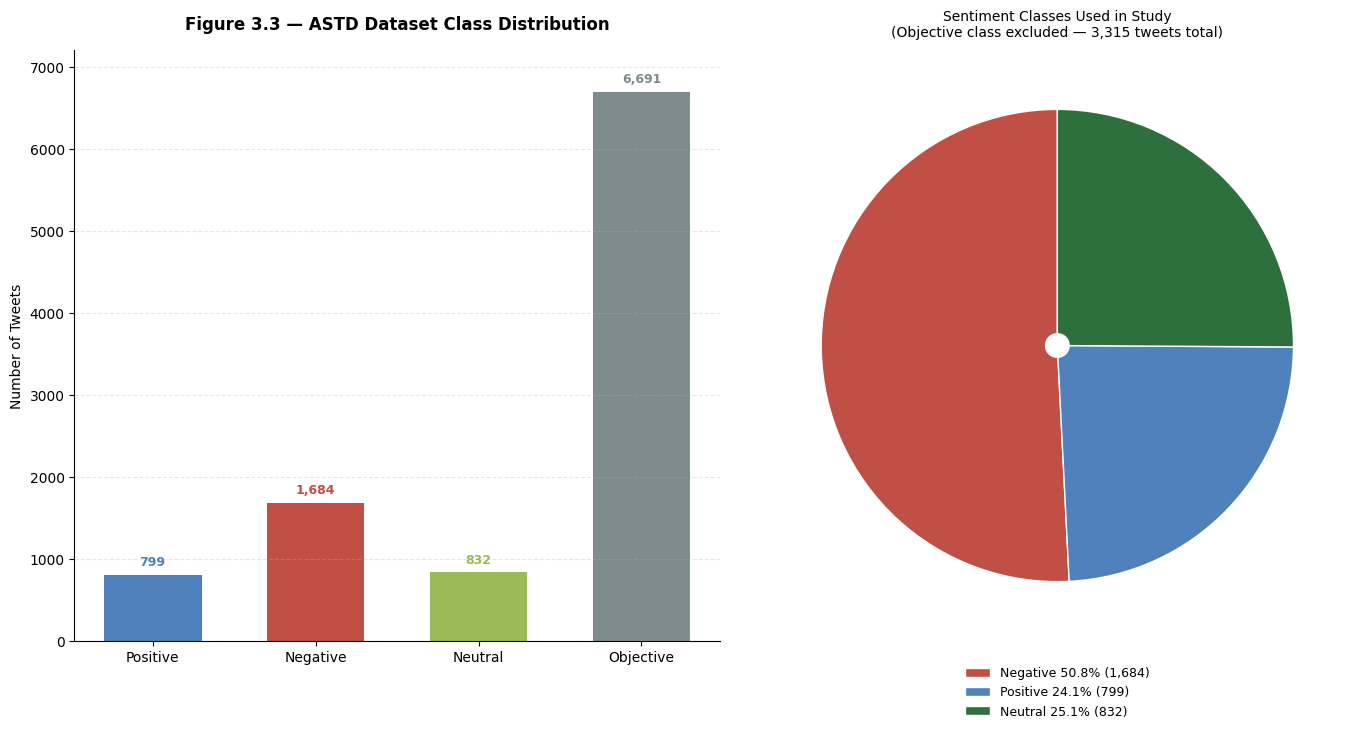

In [9]:
import matplotlib.pyplot as plt

# Figure 3.3 - ASTD Dataset Class Distribution

# Counts
full_counts = df["label"].value_counts()
full_counts = full_counts.reindex(["POS", "NEG", "NEUTRAL", "OBJ"])

sent_counts = df_sent["label"].value_counts()
sent_counts = sent_counts.reindex(["NEG", "POS", "NEUTRAL"])

# Colors
bar_colors = ["#4F81BD", "#C05046", "#9BBB59", "#7F8C8D"]
pie_colors = ["#C05046", "#4F81BD", "#2E6F3E"]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("white")

# -------------------------
# Left: Bar chart
# -------------------------
ax1 = axes[0]
bars = ax1.bar(
    ["Positive", "Negative", "Neutral", "Objective"],
    full_counts.values,
    color=bar_colors,
    edgecolor="none",
    width=0.6
)

ax1.set_title("Figure 3.3 — ASTD Dataset Class Distribution", fontsize=12, fontweight="bold", pad=15)
ax1.set_ylabel("Number of Tweets", fontsize=10)
ax1.set_ylim(0, 7200)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Add numbers above bars
for bar, value, color in zip(bars, full_counts.values, bar_colors):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 80,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=color
    )

# -------------------------
# Right: Pie chart
# -------------------------
ax2 = axes[1]

total_sent = sent_counts.sum()
percentages = sent_counts / total_sent * 100

labels = [
    f"Negative {percentages['NEG']:.1f}% ({sent_counts['NEG']:,})",
    f"Positive {percentages['POS']:.1f}% ({sent_counts['POS']:,})",
    f"Neutral {percentages['NEUTRAL']:.1f}% ({sent_counts['NEUTRAL']:,})"
]

wedges, texts = ax2.pie(
    sent_counts.values,
    colors=pie_colors,
    startangle=90,
    wedgeprops={"width": 0.95, "edgecolor": "white"}
)

ax2.set_title("Sentiment Classes Used in Study\n(Objective class excluded — 3,315 tweets total)",
              fontsize=10, pad=10)

ax2.legend(
    wedges,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    fontsize=9,
    frameon=False
)

# -------------------------
# Final Layout and Save
# -------------------------

# Adjusted layout to remove the empty space at the bottom that was left for the text
plt.tight_layout()

# Save high-quality image
plt.savefig("Figure_3_3_ASTD_Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

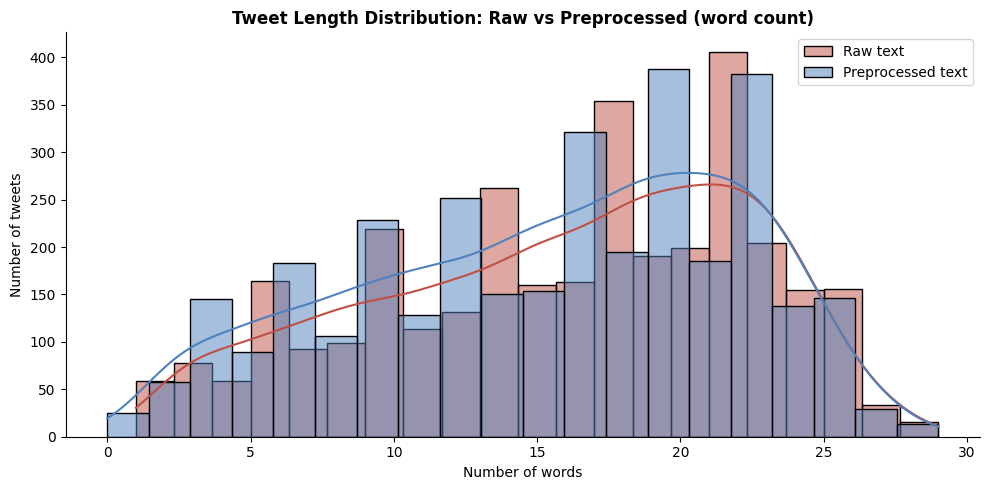

Average word count - Raw   : 15.88
Average word count - Clean : 15.46


In [10]:
# Figure — Tweet length distribution (RAW vs CLEAN)
import seaborn as sns

raw_lengths   = df_sent["raw_text"].apply(lambda x: len(x.split()))
clean_lengths = df_sent["clean_text"].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(raw_lengths, color="#C05046", label="Raw text", kde=True, alpha=0.5, ax=ax)
sns.histplot(clean_lengths, color="#4F81BD", label="Preprocessed text", kde=True, alpha=0.5, ax=ax)

ax.set_title("Tweet Length Distribution: Raw vs Preprocessed (word count)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of tweets")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Figure_Tweet_Length_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Average word count - Raw   :", raw_lengths.mean().round(2))
print("Average word count - Clean :", clean_lengths.mean().round(2))

In [11]:

import io

uploaded_train = files.upload()  #training_data.csv
uploaded_test  = files.upload()  # testing_data.csv


train_filename = list(uploaded_train.keys())[0]
test_filename  = list(uploaded_test.keys())[0]

arc_train = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))
arc_test  = pd.read_csv(io.BytesIO(uploaded_test[test_filename]))
arc_all   = pd.concat([arc_train, arc_test], ignore_index=True)

print("Shape:", arc_all.shape)
print("Columns:", arc_all.columns.tolist())
print("\nDialects:")
print(arc_all["dialect"].value_counts())
print("\nSentiment values:", arc_all["sentiment"].unique())

Saving training_data.csv to training_data (1).csv


Saving testing_data.csv to testing_data (1).csv
Shape: (15548, 4)
Columns: ['tweet', 'sarcasm', 'sentiment', 'dialect']

Dialects:
dialect
msa       10885
egypt      2981
gulf        966
levant      671
magreb       45
Name: count, dtype: int64

Sentiment values: ['NEU' 'NEG' 'POS']


In [12]:
# Filter Egyptian only and build raw_text / clean_text
egypt_arc = arc_all[arc_all["dialect"] == "egypt"][["tweet", "sentiment"]].copy()

arc_label_map = {"POS": "POS", "NEG": "NEG", "NEU": "NEUTRAL"}
egypt_arc["label"] = egypt_arc["sentiment"].map(arc_label_map)
egypt_arc = egypt_arc.dropna(subset=["label"]).reset_index(drop=True)
egypt_arc["label_id"]   = egypt_arc["label"].map(label2id)
egypt_arc["raw_text"]   = egypt_arc["tweet"].astype(str)
egypt_arc["clean_text"] = egypt_arc["tweet"].apply(preprocess_text)

print("Egyptian tweets from ArSarcasm-v2:")
print(egypt_arc["label"].value_counts())
print("Shape:", egypt_arc.shape)

Egyptian tweets from ArSarcasm-v2:
label
NEG        1564
NEUTRAL     893
POS         524
Name: count, dtype: int64
Shape: (2981, 6)


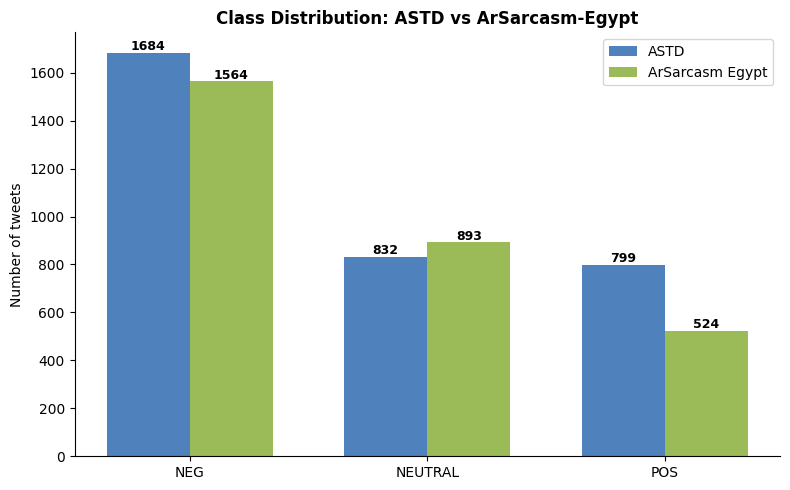


Combined total per class:
label
NEG        3248
NEUTRAL    1725
POS        1323
Name: count, dtype: int64


In [13]:
# Figure — Combined training data class distribution (ASTD + ArSarcasm Egypt)
astd_counts = df_sent["label"].value_counts().reindex(["NEG", "NEUTRAL", "POS"])
arc_counts  = egypt_arc["label"].value_counts().reindex(["NEG", "NEUTRAL", "POS"])
combined_counts = astd_counts.add(arc_counts, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35

ax.bar(x - width/2, astd_counts.values, width, label="ASTD", color="#4F81BD")
ax.bar(x + width/2, arc_counts.values, width, label="ArSarcasm Egypt", color="#9BBB59")

ax.set_xticks(x)
ax.set_xticklabels(["NEG", "NEUTRAL", "POS"])
ax.set_ylabel("Number of tweets")
ax.set_title("Class Distribution: ASTD vs ArSarcasm-Egypt", fontsize=12, fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, (a, b) in enumerate(zip(astd_counts.values, arc_counts.values)):
    ax.text(i - width/2, a + 10, str(int(a)), ha="center", fontsize=9, fontweight="bold")
    ax.text(i + width/2, b + 10, str(int(b)), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("Figure_Combined_Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCombined total per class:")
print(combined_counts)

In [14]:
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [15]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding=False
        )

        item = {key: torch.tensor(val) for key, val in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

In [17]:
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# Focal Loss — أقوى من class weights العادية للداتا المتفاوتة
# يركز على الأمثلة الصعبة (POS, NEUTRAL) ويقلل تأثير الأمثلة السهلة (NEG)
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(logits, labels, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


class CustomTrainer(Trainer):
    """Trainer يدعم class weights عادية أو Focal Loss"""
    def __init__(self, class_weights=None, use_focal_loss=False, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_gamma = focal_gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        weights = None
        if self.class_weights is not None:
            weights = torch.tensor(self.class_weights, dtype=torch.float).to(logits.device)

        if self.use_focal_loss:
            loss_fct = FocalLoss(alpha=weights, gamma=self.focal_gamma)
        else:
            loss_fct = CrossEntropyLoss(weight=weights)

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def freeze_bert_layers(model, num_layers_to_freeze=10):
    """
    يجمّد أول N طبقة من الـ 12 transformer layer في AraBERT.
    البقاء فقط على آخر طبقات قابلة للتدريب — هاد يمثل النموذج الأساسي (Baseline)
    الذي لا يستفيد بالكامل من القدرة التمثيلية للنموذج.
    """
    # جمّد embeddings
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False

    # جمّد أول num_layers_to_freeze من encoder layers
    for layer in model.bert.encoder.layer[:num_layers_to_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return model


def build_model(freeze_layers=0):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )
    if freeze_layers > 0:
        model = freeze_bert_layers(model, num_layers_to_freeze=freeze_layers)
    return model


def run_training(
    model,
    train_texts, val_texts,
    train_labels, val_labels,
    run_name,
    use_class_weights=False,
    use_focal_loss=False,
    focal_gamma=2.0,
    num_epochs=5,
    learning_rate=2e-5
):
    """يدرب موديل معطى على داتا معطاة - يستخدم للـ stage1/stage2 وللتدريب العادي"""
    train_dataset = TweetDataset(train_texts, train_labels, tokenizer, MAX_LEN)
    val_dataset   = TweetDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=f"./{run_name}_outputs",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        warmup_steps=42,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none"
    )

    weights = None
    if use_class_weights:
        weights = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1, 2]),
            y=train_labels.values
        ).tolist()
        print(f"Class weights: NEG={weights[0]:.3f} | NEUTRAL={weights[1]:.3f} | POS={weights[2]:.3f}")

    if use_class_weights or use_focal_loss:
        trainer = CustomTrainer(
            class_weights=weights,
            use_focal_loss=use_focal_loss,
            focal_gamma=focal_gamma,
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics
        )
    else:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics
        )

    trainer.train()
    return trainer


def evaluate_on_test(trainer, test_texts, test_labels, run_name):
    """يقيّم trainer مدرّب على test set ويحفظ النتائج"""
    test_dataset = TweetDataset(test_texts, test_labels, tokenizer, MAX_LEN)

    val_results = trainer.evaluate(eval_dataset=test_dataset)
    print(f"\nFinal Eval - {run_name}")
    print(val_results)

    predictions = trainer.predict(test_dataset)
    test_preds = np.argmax(predictions.predictions, axis=1)
    test_true  = test_labels.values

    report = classification_report(
        test_true, test_preds,
        target_names=["NEG", "NEUTRAL", "POS"],
        digits=4, zero_division=0
    )

    acc = accuracy_score(test_true, test_preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        test_true, test_preds, average="macro", zero_division=0
    )
    cm = confusion_matrix(test_true, test_preds)

    print(f"\nTest Results - {run_name}")
    print("Accuracy   :", acc)
    print("Macro Prec :", p_macro)
    print("Macro Rec  :", r_macro)
    print("Macro F1   :", f1_macro)
    print("\nClassification Report:")
    print(report)
    print("\nConfusion Matrix:\n", cm)

    os.makedirs("results", exist_ok=True)
    with open(f"results/{run_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)
        f.write(f"\n\nAccuracy: {acc}\nMacro Precision: {p_macro}\n")
        f.write(f"Macro Recall: {r_macro}\nMacro F1: {f1_macro}\n")
        f.write("\nConfusion Matrix:\n" + str(cm))

    pred_df = pd.DataFrame({
        "text": test_texts.values if hasattr(test_texts, "values") else list(test_texts),
        "true_label_id": test_true,
        "pred_label_id": test_preds,
        "true_label": [id2label[x] for x in test_true],
        "pred_label": [id2label[x] for x in test_preds]
    })
    pred_df.to_csv(f"results/{run_name}_test_predictions.csv", index=False, encoding="utf-8-sig")

    return {
        "run_name": run_name,
        "accuracy": acc,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f1_macro,
        "confusion_matrix": cm,
        "classification_report": report
    }


In [18]:
# ============================================================
# Baseline split — ASTD only
# ============================================================
train_base, temp_base = train_test_split(
    df_sent,
    test_size=0.2,
    random_state=42,
    stratify=df_sent["label_id"]
)
val_base, test_base = train_test_split(
    temp_base,
    test_size=0.5,
    random_state=42,
    stratify=temp_base["label_id"]
)

print("=== Baseline (ASTD only) ===")
print("Train:", train_base.shape, "| Val:", val_base.shape, "| Test:", test_base.shape)
print("train_base columns:", train_base.columns.tolist())

# ============================================================
# Proposed split — ASTD train + ArSarcasm Egyptian (clean text)
# Val/Test stay the same as baseline -> fair comparison
# ============================================================
test_prop = test_base.copy()
val_prop  = val_base.copy()

astd_train_prop = train_base[["clean_text", "label_id"]].copy()
arc_train_prop  = egypt_arc[["clean_text", "label_id"]].copy()

train_prop = pd.concat([astd_train_prop, arc_train_prop], ignore_index=True)
train_prop = train_prop.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n=== Proposed (ASTD + ArSarcasm Egyptian) ===")
print("Train:", train_prop.shape, "| Val:", val_prop.shape, "| Test:", test_prop.shape)
print("\nProposed train label distribution:")
print(train_prop["label_id"].value_counts())

=== Baseline (ASTD only) ===
Train: (2652, 5) | Val: (331, 5) | Test: (332, 5)
train_base columns: ['tweet', 'label', 'label_id', 'raw_text', 'clean_text']

=== Proposed (ASTD + ArSarcasm Egyptian) ===
Train: (5633, 2) | Val: (331, 5) | Test: (332, 5)

Proposed train label distribution:
label_id
0    2911
1    1559
2    1163
Name: count, dtype: int64


In [19]:
print("=" * 60)
print("Training BASELINE model")
print("Data       : ASTD only (raw text, no preprocessing)")
print("Train size :", len(train_base))
print("Setup      : 10/12 BERT layers frozen, no class weights, 3 epochs")
print("=" * 60)

baseline_model = build_model(freeze_layers=10)

baseline_trainer = run_training(
    model=baseline_model,
    train_texts=train_base["raw_text"],
    val_texts=val_base["raw_text"],
    train_labels=train_base["label_id"],
    val_labels=val_base["label_id"],
    run_name="baseline_raw",
    use_class_weights=False,
    use_focal_loss=False,
    num_epochs=3,
    learning_rate=2e-5
)

baseline_results = evaluate_on_test(
    baseline_trainer,
    test_texts=test_base["raw_text"],
    test_labels=test_base["label_id"],
    run_name="baseline_raw"
)

Training BASELINE model
Data       : ASTD only (raw text, no preprocessing)
Train size : 2652
Setup      : 10/12 BERT layers frozen, no class weights, 3 epochs


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,768,643 / 135,195,651 (10.92%)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.781303,0.814244,3,0.641566,0.603094,0.564424,0.561694,0.617465,0.641566,0.609465



Final Eval - baseline_raw
{'eval_loss': 0.8142440319061279, 'eval_accuracy': 0.641566265060241, 'eval_precision_macro': 0.6030940442705148, 'eval_recall_macro': 0.5644242651077683, 'eval_f1_macro': 0.5616938616938617, 'eval_precision_weighted': 0.617465090888195, 'eval_recall_weighted': 0.641566265060241, 'eval_f1_weighted': 0.609465133260314}



Test Results - baseline_raw
Accuracy   : 0.641566265060241
Macro Prec : 0.6030940442705148
Macro Rec  : 0.5644242651077683
Macro F1   : 0.5616938616938617

Classification Report:
              precision    recall  f1-score   support

         NEG     0.6606    0.8639    0.7487       169
     NEUTRAL     0.4865    0.2169    0.3000        83
         POS     0.6622    0.6125    0.6364        80

    accuracy                         0.6416       332
   macro avg     0.6031    0.5644    0.5617       332
weighted avg     0.6175    0.6416    0.6095       332


Confusion Matrix:
 [[146  12  11]
 [ 51  18  14]
 [ 24   7  49]]


In [20]:
print("=" * 60)
print("Training PROPOSED model — Two-Stage Domain Adaptation")
print("=" * 60)

# -------------------------
# Stage 1: Pretraining on ArSarcasm Egyptian (clean text, full fine-tuning)
# -------------------------
print("\n--- Stage 1: Pretraining on ArSarcasm-v2 Egyptian ---")
print("Train size:", len(egypt_arc))

# split صغير من egypt_arc كـ val للـ stage 1
arc_train_s1, arc_val_s1 = train_test_split(
    egypt_arc, test_size=0.1, random_state=42, stratify=egypt_arc["label_id"]
)

proposed_model = build_model(freeze_layers=0)  # full fine-tuning، بدون تجميد

stage1_trainer = run_training(
    model=proposed_model,
    train_texts=arc_train_s1["clean_text"],
    val_texts=arc_val_s1["clean_text"],
    train_labels=arc_train_s1["label_id"],
    val_labels=arc_val_s1["label_id"],
    run_name="proposed_stage1",
    use_class_weights=False,
    use_focal_loss=False,
    num_epochs=3,
    learning_rate=2e-5
)

# -------------------------
# Stage 2: Fine-tuning on ASTD train (clean text) مع Focal Loss + class weights
# -------------------------
print("\n--- Stage 2: Fine-tuning on ASTD with Focal Loss + class weights ---")
print("Train size:", len(train_prop))

# الموديل المدرب من Stage 1 نستمر بتدريبه
stage2_model = stage1_trainer.model

stage2_trainer = run_training(
    model=stage2_model,
    train_texts=train_base["clean_text"],
    val_texts=val_base["clean_text"],
    train_labels=train_base["label_id"],
    val_labels=val_base["label_id"],
    run_name="proposed_stage2",
    use_class_weights=True,
    use_focal_loss=True,
    focal_gamma=2.0,
    num_epochs=7,
    learning_rate=1e-5   # أصغر — fine-tuning أدق على موديل مُدرّب مسبقاً
)

# -------------------------
# Final Evaluation on ASTD test (نفس test set الباسلاين)
# -------------------------
proposed_results = evaluate_on_test(
    stage2_trainer,
    test_texts=test_base["clean_text"],
    test_labels=test_base["label_id"],
    run_name="proposed_final"
)

Training PROPOSED model — Two-Stage Domain Adaptation

--- Stage 1: Pretraining on ArSarcasm-v2 Egyptian ---
Train size: 2981


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.865127,0.745078,0.672241,0.631427,0.641604,0.631730,0.668315,0.672241,0.666536
2,0.629166,0.722447,0.688963,0.647643,0.661703,0.651840,0.690083,0.688963,0.687678
3,0.467727,0.814453,0.672241,0.638303,0.658990,0.646417,0.683287,0.672241,0.675985


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.093026,0.392380,7,0.680723,0.686703,0.698144,0.678157,0.733806,0.680723,0.691737



Final Eval - proposed_final
{'eval_loss': 0.39238041639328003, 'eval_accuracy': 0.6807228915662651, 'eval_precision_macro': 0.6867030584591559, 'eval_recall_macro': 0.698143758465816, 'eval_f1_macro': 0.678157153015155, 'eval_precision_weighted': 0.7338057176440955, 'eval_recall_weighted': 0.6807228915662651, 'eval_f1_weighted': 0.6917374127830553}



Test Results - proposed_final
Accuracy   : 0.6807228915662651
Macro Prec : 0.6867030584591559
Macro Rec  : 0.698143758465816
Macro F1   : 0.678157153015155

Classification Report:
              precision    recall  f1-score   support

         NEG     0.8699    0.6331    0.7329       169
     NEUTRAL     0.4640    0.6988    0.5577        83
         POS     0.7262    0.7625    0.7439        80

    accuracy                         0.6807       332
   macro avg     0.6867    0.6981    0.6782       332
weighted avg     0.7338    0.6807    0.6917       332


Confusion Matrix:
 [[107  50  12]
 [ 14  58  11]
 [  2  17  61]]


In [21]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline (Raw Tweets)",
        "Accuracy": baseline_results["accuracy"],
        "Macro Precision": baseline_results["macro_precision"],
        "Macro Recall": baseline_results["macro_recall"],
        "Macro F1": baseline_results["macro_f1"]
    },
    {
        "Model": "Proposed (Preprocessed Tweets)",
        "Accuracy": proposed_results["accuracy"],
        "Macro Precision": proposed_results["macro_precision"],
        "Macro Recall": proposed_results["macro_recall"],
        "Macro F1": proposed_results["macro_f1"]
    }
])

comparison_df.to_csv("results/model_comparison.csv", index=False, encoding="utf-8-sig")

print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
                            Model  Accuracy  Macro Precision  Macro Recall  \
0           Baseline (Raw Tweets)  0.641566         0.603094      0.564424   
1  Proposed (Preprocessed Tweets)  0.680723         0.686703      0.698144   

   Macro F1  
0  0.561694  
1  0.678157  


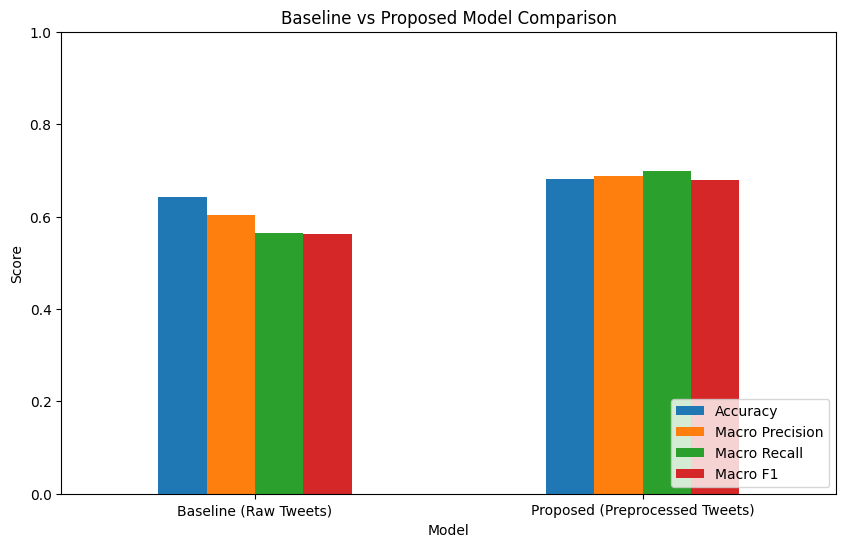

In [22]:
comparison_df_plot = comparison_df.set_index("Model")
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]

comparison_df_plot[metrics].plot(kind="bar", figsize=(10, 6))
plt.title("Baseline vs Proposed Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

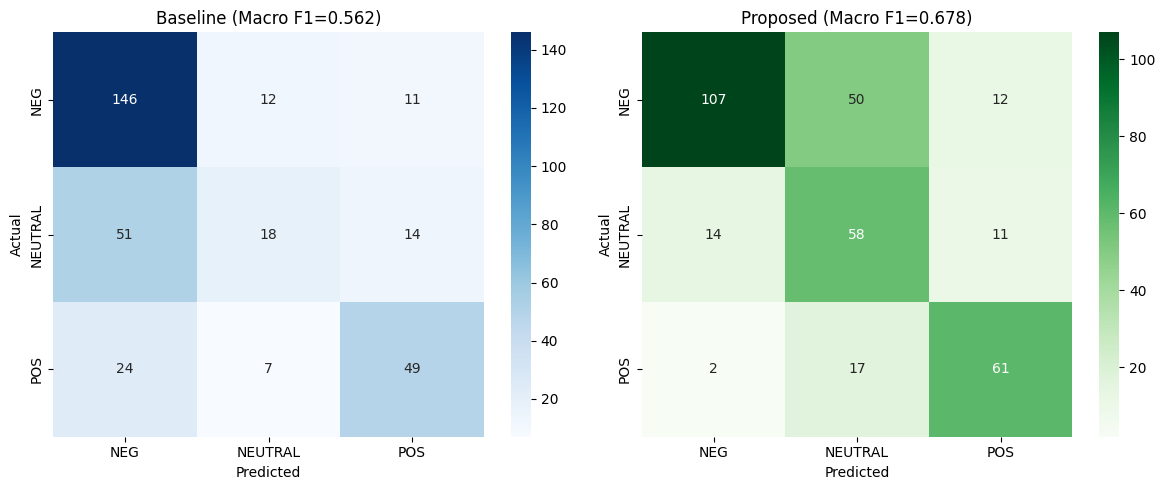

In [23]:
# Figure — Confusion matrices: Baseline vs Proposed
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    baseline_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
    xticklabels=["NEG", "NEUTRAL", "POS"],
    yticklabels=["NEG", "NEUTRAL", "POS"],
    ax=axes[0]
)
axes[0].set_title(f"Baseline (Macro F1={baseline_results['macro_f1']:.3f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    proposed_results["confusion_matrix"], annot=True, fmt="d", cmap="Greens",
    xticklabels=["NEG", "NEUTRAL", "POS"],
    yticklabels=["NEG", "NEUTRAL", "POS"],
    ax=axes[1]
)
axes[1].set_title(f"Proposed (Macro F1={proposed_results['macro_f1']:.3f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("Figure_Confusion_Matrices.png", dpi=300, bbox_inches="tight")
plt.show()

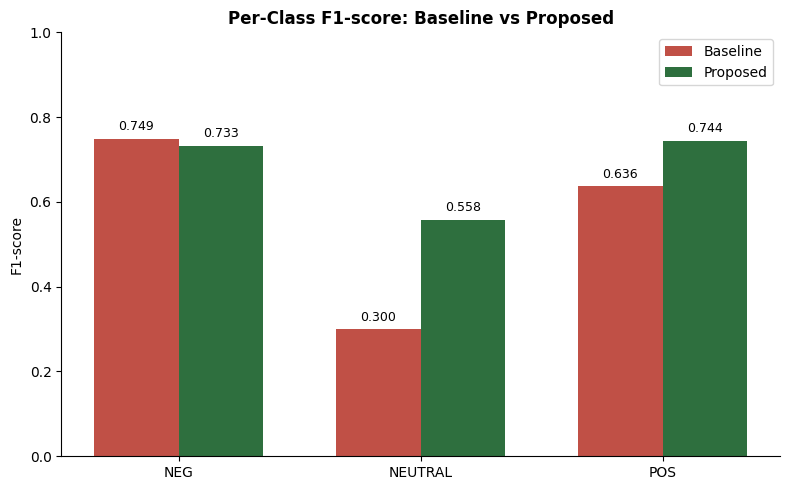

In [24]:
# Figure — Per-class F1-score: Baseline vs Proposed
from sklearn.metrics import f1_score

def per_class_f1(cm):
    """يحسب F1 لكل صف من confusion matrix"""
    f1s = []
    for i in range(3):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        f1s.append(f1)
    return f1s

base_f1 = per_class_f1(baseline_results["confusion_matrix"])
prop_f1 = per_class_f1(proposed_results["confusion_matrix"])

classes = ["NEG", "NEUTRAL", "POS"]
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, base_f1, width, label="Baseline", color="#C05046")
ax.bar(x + width/2, prop_f1, width, label="Proposed", color="#2E6F3E")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1)
ax.set_title("Per-Class F1-score: Baseline vs Proposed", fontsize=12, fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, (b, p) in enumerate(zip(base_f1, prop_f1)):
    ax.text(i - width/2, b + 0.02, f"{b:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, p + 0.02, f"{p:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("Figure_PerClass_F1.png", dpi=300, bbox_inches="tight")
plt.show()